# Applying the Trained Models

This notebook applies trained PINN-MSCNN models to the MODEST Hinode/SP dataset and performs comprehensive analysis including:
- Model loading and inference with uncertainty quantification (Monte Carlo Dropout)
- Spatial maps comparison (predictions vs ground truth)
- Statistical analysis (correlation, RMSE, bias)
- Vertical atmospheric profile comparison
- Multi-model comparison (no physics, WFA only, all physics)
- Error analysis across optical depths

## 0. Prerequisites

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import torch
import astropy.units as u
from pathlib import Path
import sys
from scipy.stats import pearsonr
import pandas as pd
from typing import Dict, Tuple, Optional

# Add parent directories to path
sys.path.append("/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN")
from utils.modest_data import ModestData
from models.pinn_mscnn_model import PhysicsInformedMSCNN
from utils.normalizer import MhdNormalizer, StokesNormalizer
from utils.analysis_functions import (
    plot_prediction_comparison,
    compare_models_at_optical_depth,
    plot_mean_vs_optical_depth,
    analyze_error_by_magnitude,
    plot_uncertainty_vs_error,
    plot_jointplot_comparison,
    plot_combined_jointplot
)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

# Base images save path
images_base_path = Path("/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images")
images_save_path = images_base_path / "modest_analysis/whole_region"

print("✓ All imports successful")

✓ All imports successful


## 1. Load MODEST Data

In [2]:
data_path = Path("/scratchsan/observatorio/juagudeloo/data")

In [3]:
modest = ModestData()
modest.load_all(apply_mask=False)
print("✓ MODEST data loaded successfully")
print(f"  Continuum shape: {modest.continuum.shape}")
print(f"  Stokes I shape: {modest.obs_stokes['I'].shape}")
print(f"  Wavelength points: {len(modest.wl)}")

✓ MODEST data loaded successfully
  Continuum shape: (390, 858)
  Stokes I shape: (390, 858, 112)
  Wavelength points: 112


In [4]:
# Load normalizers
mhd_normalizer = MhdNormalizer()
mhd_normalizer.load(data_path / "normalization_stats/mhd_normalization.json")

stokes_normalizer = StokesNormalizer()
stokes_normalizer.load(data_path / "normalization_stats/stokes_normalization.json")

# Normalize Stokes data
normalized_stokes = stokes_normalizer.transform(modest.obs_stokes)
print("✓ Normalizers loaded and Stokes data normalized")

Per-τ normalization statistics loaded from /scratchsan/observatorio/juagudeloo/data/normalization_stats/mhd_normalization.json
Optical depth levels: 21
Stokes normalization statistics loaded from /scratchsan/observatorio/juagudeloo/data/normalization_stats/stokes_normalization.json
✓ Normalizers loaded and Stokes data normalized


## 2. Visualize FOV and Disk Center

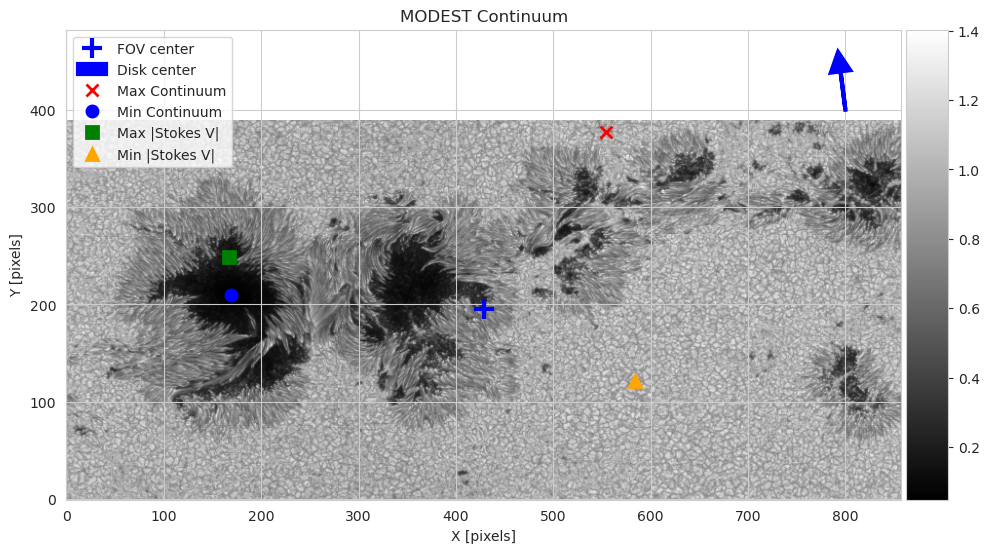

In [5]:
y_center_fov_arcsec = -126.0
x_center_fov_arcsec = 16.0
pixel_scale = 0.32
x_center_fov_pixel = modest.continuum.shape[1] / 2
y_center_fov_pixel = modest.continuum.shape[0] / 2
x_disk_offset_arcsec = 0 - x_center_fov_arcsec
y_disk_offset_arcsec = 0 - y_center_fov_arcsec
x_disk_offset_pixels = x_disk_offset_arcsec / pixel_scale
y_disk_offset_pixels = y_disk_offset_arcsec / pixel_scale
x_disk_center = x_center_fov_pixel + x_disk_offset_pixels
y_disk_center = y_center_fov_pixel + y_disk_offset_pixels
arrow_start_x = 800
arrow_start_y = 400
arrow_dx = x_disk_offset_pixels/10
arrow_dy = y_disk_offset_pixels/10

modest.plot_continuum(
    x_center_fov_pixel=x_center_fov_pixel,
    y_center_fov_pixel=y_center_fov_pixel,
    disk_center=(x_disk_center, y_disk_center),
    arrow_params=(arrow_start_x, arrow_start_y, arrow_dx, arrow_dy)
)

## 3. Load and Compare Multiple Models

We'll load three models trained with different physics regularization:
1. **No Physics**: Pure supervised learning
2. **WFA Only**: Weak-Field Approximation for B_LOS
3. **All Physics**: WFA + Gradient Smoothness

In [6]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Model configurations to compare
model_configs = {
    'no_physics_60_to_100': {
        'path': '/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/output/experiments/physics_regularization_ablation_60_to_100/no_physics/final_model.pth',
        'use_physics': None,
        'lambda_wfa': 0.0,
        'lambda_doppler': 0.0,
        'lambda_temp': 0.0,
        'lambda_physics': 0.0,
        'label': 'No Physics 60 to 100',
        'color': 'blue'
    },
    'wfa_only_60_to_100': {
        'path': '/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/output/experiments/physics_regularization_ablation_60_to_100/wfa_only/final_model.pth',
        'use_physics': 'wfa',
        'lambda_wfa': 0.01,
        'lambda_doppler': 0.0,
        'lambda_temp': 0.0,
        'lambda_physics': 0.0,
        'label': 'WFA Only 60 to 100',
        'color': 'orange'
    },
    'all_physics_60_to_100': {
        'path': '/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/output/experiments/physics_regularization_ablation_60_to_100/all_physics_terms/final_model.pth',
        'use_physics': 'wfa',
        'lambda_wfa': 0.01,
        'lambda_doppler': 0.0,
        'lambda_temp': 0.0,
        'lambda_physics': 0.02,
        'label': 'All Physics 60 to 100',
        'color': 'green'
    },
    "no_physics_100_to_200": {
        'path': '/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/output/experiments/physics_regularization_ablation_100_to_200/no_physics/final_model.pth',
        'use_physics': None,
        'lambda_wfa': 0.0,
        'lambda_doppler': 0.0,
        'lambda_temp': 0.0,
        'lambda_physics': 0.0,
        'label': 'No Physics 100 to 200',
        'color': 'blue'
    },
    'wfa_only_100_to_200': {
        'path': '/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/output/experiments/physics_regularization_ablation_100_to_200/wfa_only/final_model.pth',
        'use_physics': 'wfa',
        'lambda_wfa': 0.01,
        'lambda_doppler': 0.0,
        'lambda_temp': 0.0,
        'lambda_physics': 0.0,
        'label': 'WFA Only 100 to 200',
        'color': 'orange'
    },
}

def load_model(config: Dict) -> PhysicsInformedMSCNN:
    """Load a trained PINN-MSCNN model."""
    model = PhysicsInformedMSCNN(
        scales=[1, 2, 3],
        in_channels=2,
        c1_filters=16,
        c2_filters=32,
        kernel_size=5,
        pool_size=2,
        n_linear_layers=4,
        output_features=3*21,
        input_length=112,
        dropout_rate=0.2,
        use_physics=config['use_physics'],
        lambda_wfa=config['lambda_wfa'],
        lambda_doppler=config['lambda_doppler'],
        lambda_temp=config['lambda_temp'],
        lambda_physics=config['lambda_physics'],
    ).to(device)
    
    # Load checkpoint
    checkpoint = torch.load(config['path'], map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    return model

# Load all models
models = {}
for name, config in model_configs.items():
    print(f"Loading {config['label']}...")
    models[name] = load_model(config)
    print(f"  ✓ Model loaded successfully")
    if 'test_metrics' in torch.load(config['path'], map_location='cpu'):
        metrics = torch.load(config['path'], map_location='cpu')['test_metrics']
        print(f"  Training metrics: B_LOS RRMSE={metrics.get('blos_rrmse_tau_avg', 'N/A'):.4f}, "
              f"V_LOS RRMSE={metrics.get('vlos_rrmse_tau_avg', 'N/A'):.4f}")

print(f"\n✓ All {len(models)} models loaded")

Using device: cuda
Loading No Physics 60 to 100...
  ✓ Model loaded successfully
  Training metrics: B_LOS RRMSE=inf, V_LOS RRMSE=1.3127
Loading WFA Only 60 to 100...
  ✓ Model loaded successfully
  Training metrics: B_LOS RRMSE=inf, V_LOS RRMSE=1.3170
Loading All Physics 60 to 100...
  ✓ Model loaded successfully
  Training metrics: B_LOS RRMSE=inf, V_LOS RRMSE=1.3163
Loading No Physics 100 to 200...
  ✓ Model loaded successfully
  Training metrics: B_LOS RRMSE=4.3830, V_LOS RRMSE=1.3212
Loading WFA Only 100 to 200...
  ✓ Model loaded successfully
  Training metrics: B_LOS RRMSE=14.4114, V_LOS RRMSE=1.3200

✓ All 5 models loaded


## 4. Prepare Input Data

In [7]:
# Prepare input tensor
I_t = normalized_stokes["I"]
V_t = normalized_stokes["V"]
inputs = np.stack([I_t, V_t], axis=2)  # Shape: (H, W, 2, nλ)
H, W, Nstokes, Nlambda = inputs.shape

# Convert to torch tensor
inputs_tensor = torch.tensor(inputs, dtype=torch.float32).permute(0, 1, 3, 2)  # (H, W, nλ, 2)
inputs_tensor = inputs_tensor.reshape(H*W, Nstokes, Nlambda).to(device)  # (H*W, 2, nλ)

print(f"Input tensor shape: {inputs_tensor.shape}")
print(f"Total pixels: {H*W:,}")

Input tensor shape: torch.Size([334620, 2, 112])
Total pixels: 334,620


## 5. Run Inference with Uncertainty Quantification

Using Monte Carlo Dropout (30 stochastic forward passes) to estimate prediction uncertainty.

In [8]:
# Run inference for all models
all_predictions = {}
logtau = np.arange(-2, 0.1, 0.1)

print("\n" + "="*70)
for model_name, model in models.items():
    print(f"\nRunning inference for {model_configs[model_name]['label']}...")
    
    # Option 1: Use the model's built-in method directly
    mean_atm, std_atm = model.run_inference_with_uncertainty(
        inputs=inputs_tensor,
        mhd_normalizer=mhd_normalizer,
        batch_size=512,
        stochastic_steps=30,
        H=H,
        W=W,
        n_heights=21,
        verbose=True
    )
    
    # Option 2: Use the wrapper function from analysis_functions (backward compatible)
    # mean_atm, std_atm = run_inference_with_uncertainty(
    #     model, inputs_tensor, mhd_normalizer,
    #     batch_size=512, stochastic_steps=30,
    #     H=H, W=W, n_heights=21
    # )
    
    all_predictions[model_name] = {
        'mean': mean_atm,
        'std': std_atm,
        'label': model_configs[model_name]['label'],
        'color': model_configs[model_name]['color']
    }
    print(f"  T range: {mean_atm['T'].min():.1f} - {mean_atm['T'].max():.1f} K")
    print(f"  Vz range: {mean_atm['Vz'].min():.2f} - {mean_atm['Vz'].max():.2f} km/s")
    print(f"  Bz range: {mean_atm['Bz'].min():.2f} - {mean_atm['Bz'].max():.2f} G")

print("\n" + "="*70)
print("✓ All model inferences complete")



Running inference for No Physics 60 to 100...
Running inference with Monte Carlo Dropout...


  Processed 0/334,620 pixels (0.0%)
  Processed 51,200/334,620 pixels (15.3%)
  Processed 102,400/334,620 pixels (30.6%)
  Processed 153,600/334,620 pixels (45.9%)
  Processed 204,800/334,620 pixels (61.2%)
  Processed 256,000/334,620 pixels (76.5%)
  Processed 307,200/334,620 pixels (91.8%)
  Stochastic predictions shape: torch.Size([30, 334620, 63])


/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/normalizer.py:189: RuntimeWarning: overflow encountered in power
  denorm_tau = sign * (10 ** np.abs(pred_log) - 1.0)
/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/numpy/core/_methods.py:176: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/numpy/core/_methods.py:187: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


  ✓ Inference complete
    T: mean range [-28042.26, 12631.39], avg std = 340.05
    Vz: mean range [-79.40, 50.67], avg std = 1.61
    Bz: mean range [-1414970490681719048229617664.00, inf], avg std = nan
  T range: -28042.3 - 12631.4 K
  Vz range: -79.40 - 50.67 km/s
  Bz range: -1414970490681719048229617664.00 - inf G

Running inference for WFA Only 60 to 100...
Running inference with Monte Carlo Dropout...
  Processed 0/334,620 pixels (0.0%)
  Processed 51,200/334,620 pixels (15.3%)
  Processed 102,400/334,620 pixels (30.6%)
  Processed 153,600/334,620 pixels (45.9%)
  Processed 204,800/334,620 pixels (61.2%)
  Processed 256,000/334,620 pixels (76.5%)
  Processed 307,200/334,620 pixels (91.8%)
  Stochastic predictions shape: torch.Size([30, 334620, 63])
  ✓ Inference complete
    T: mean range [-20295.04, 11511.65], avg std = 197.35
    Vz: mean range [-33.31, 31.58], avg std = 1.10
    Bz: mean range [-99876883090055888896.00, 218627173253120.00], avg std = inf
  T range: -20295.0

## 6. Analysis Functions

Analysis functions have been moved to `utils/analysis_functions.py` for reusability.

## 7. Single Model Analysis

Analyze each model individually at a specific optical depth.

In [9]:
modest_logtau = list(modest.spinor_atm["T"].keys())

/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/prediction_comparison/no_physics_60_to_100_comparison_Bz_logtau_-2.0.json

Summary for No Physics 60 to 100: Line-of-sight Magnetic Field at log(τ)=-2.0
Pearson R:   0.0016 (p-value: 3.41e-01)
RMSE:        22185015296.000 G
Bias:        -54564872.000 G
Mean σ:      293851136.000 G
Median σ:    3.745 G

✓ Saved comparison plot for No Physics 60 to 100 at log(tau)=-2.0 for Bz
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/prediction_comparison/wfa_only_60_to_100_comparison_Bz_logtau_-2.0.json

Summary for WFA Only 60 to 100: Line-of-sight Magnetic Field at log(τ)=-2.0
Pearson R:   0.0066 (p-value: 1.45e-04)
RMSE:        145557.938 G
Bias:        -980.623 G
Mean σ:      4727.539 G
Median σ:    1.536 G

✓ Saved comparison plot for WFA Only 60 to 100 at log(tau)=-2.0 for Bz


/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:99: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean(difference**2))


  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/prediction_comparison/all_physics_60_to_100_comparison_Bz_logtau_-2.0.json

Summary for All Physics 60 to 100: Line-of-sight Magnetic Field at log(τ)=-2.0
Pearson R:   0.0031 (p-value: 7.37e-02)
RMSE:        inf G
Bias:        -71765061533696.000 G
Mean σ:      inf G
Median σ:    4.047 G

✓ Saved comparison plot for All Physics 60 to 100 at log(tau)=-2.0 for Bz
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/prediction_comparison/no_physics_100_to_200_comparison_Bz_logtau_-2.0.json

Summary for No Physics 100 to 200: Line-of-sight Magnetic Field at log(τ)=-2.0
Pearson R:   0.0013 (p-value: 4.43e-01)
RMSE:        7095723.500 G
Bias:        -23417.404 G
Mean σ:      70752.570 G
Median σ:    2.799 G

✓ Saved comparison plot for No Physics 100 to 200 at log(tau)=-2.0 for Bz
  ✓ Metrics saved to /scratchsan/observator

/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/numpy/core/_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/prediction_comparison/wfa_only_100_to_200_comparison_Bz_logtau_-0.8.json

Summary for WFA Only 100 to 200: Line-of-sight Magnetic Field at log(τ)=-0.8
Pearson R:   0.0060 (p-value: 5.62e-04)
RMSE:        inf G
Bias:        734267334046253056.000 G
Mean σ:      inf G
Median σ:    16.495 G

✓ Saved comparison plot for WFA Only 100 to 200 at log(tau)=-0.8 for Bz
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/prediction_comparison/no_physics_60_to_100_comparison_Vz_logtau_-0.8.json

Summary for No Physics 60 to 100: Line-of-sight Velocity at log(τ)=-0.8
Pearson R:   -0.1401 (p-value: 0.00e+00)
RMSE:        3.282 km/s
Bias:        0.033 km/s
Mean σ:      1.393 km/s
Median σ:    0.814 km/s

✓ Saved comparison plot for No Physics 60 to 100 at log(tau)=-0.8 for Vz
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo

/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4623: RuntimeWarning: invalid value encountered in subtract
  xm = x - xmean


  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/prediction_comparison/wfa_only_60_to_100_comparison_Bz_logtau_0.0.json

Summary for WFA Only 60 to 100: Line-of-sight Magnetic Field at log(τ)=0.0
Pearson R:   -0.0042 (p-value: 1.62e-02)
RMSE:        inf G
Bias:        -596993072168960.000 G
Mean σ:      inf G
Median σ:    36.044 G

✓ Saved comparison plot for WFA Only 60 to 100 at log(tau)=0.0 for Bz
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/prediction_comparison/all_physics_60_to_100_comparison_Bz_logtau_0.0.json

Summary for All Physics 60 to 100: Line-of-sight Magnetic Field at log(τ)=0.0
Pearson R:   -0.0029 (p-value: 9.18e-02)
RMSE:        inf G
Bias:        -131820572460539700502469804032.000 G
Mean σ:      inf G
Median σ:    255.518 G

✓ Saved comparison plot for All Physics 60 to 100 at log(tau)=0.0 for Bz
  ✓ Metrics saved to /scratchsan/observat

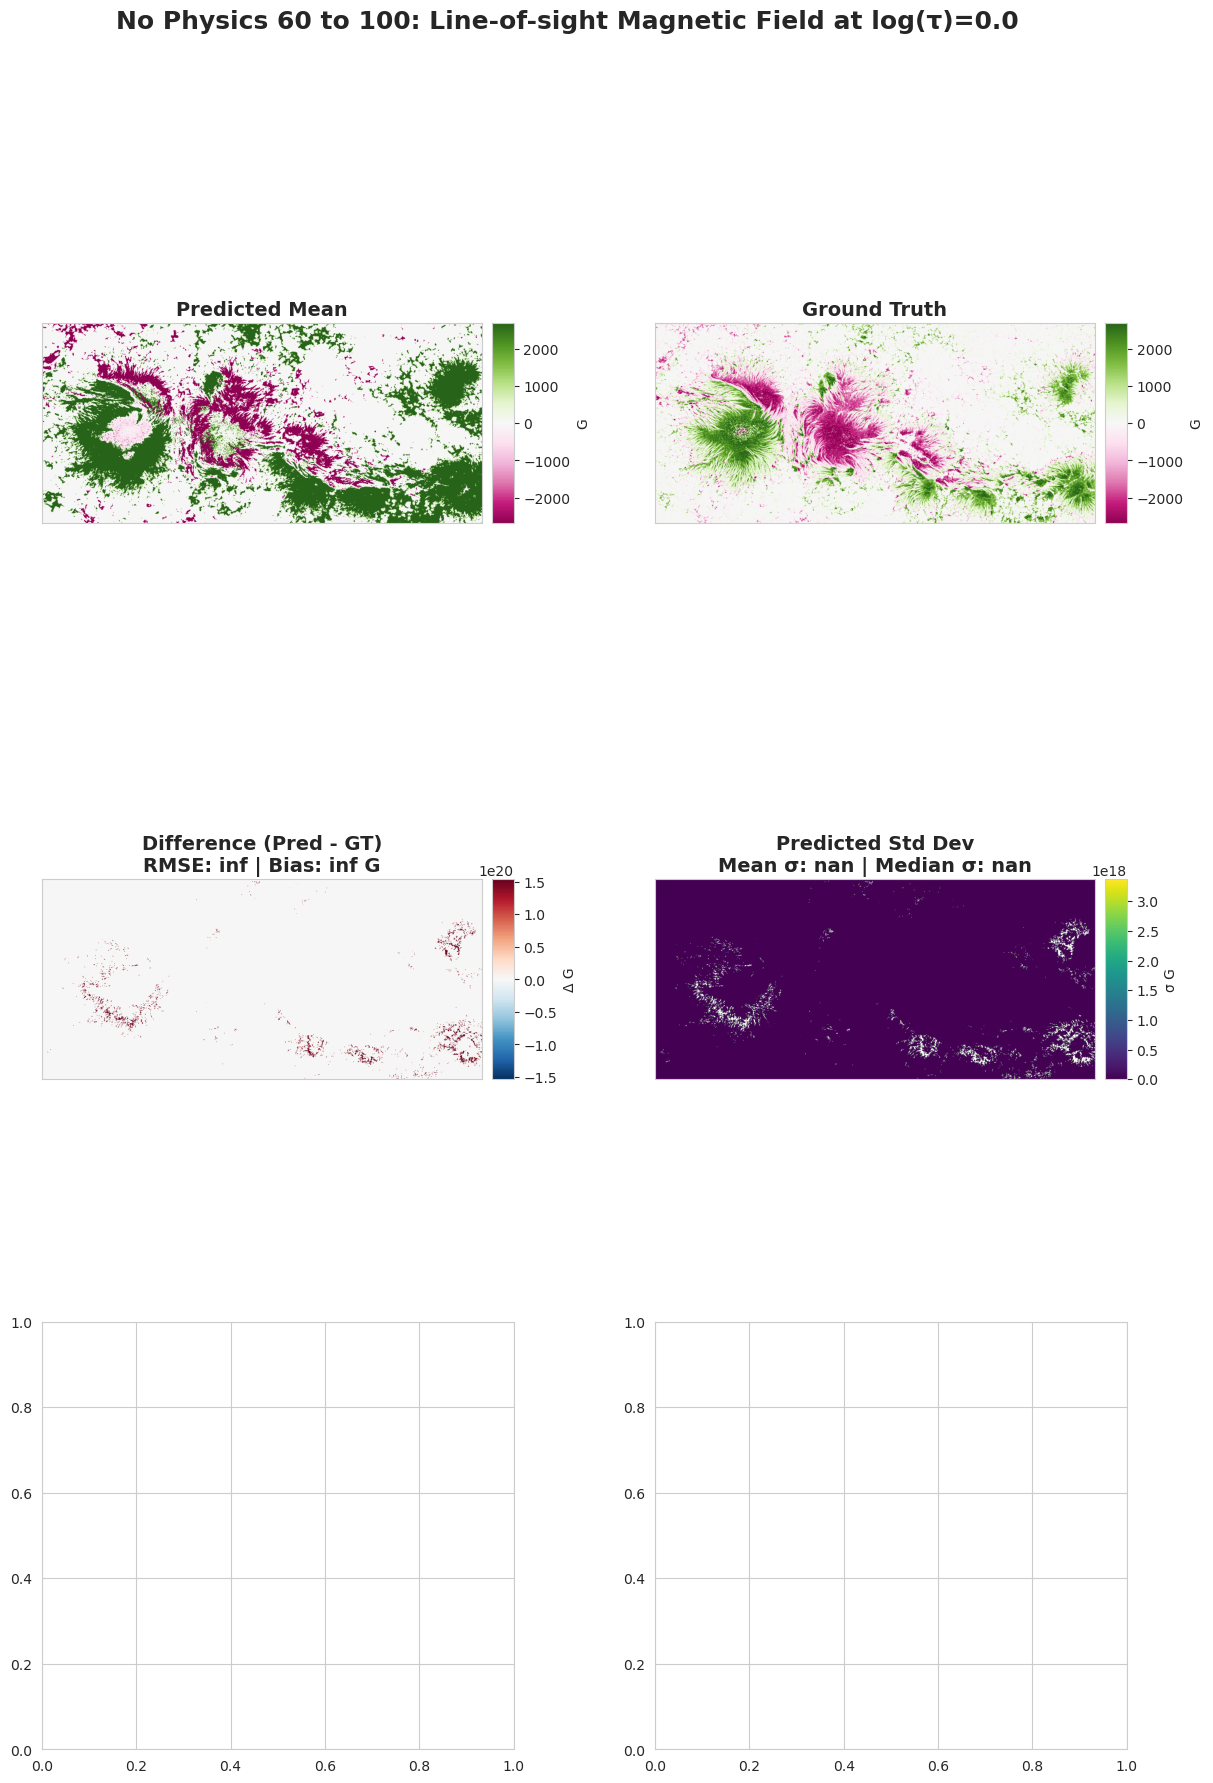

In [10]:
# Choose optical depth and parameter
logtau = np.arange(-2, 0.1, 0.1)

# Plot each model
for od_to_plot in modest_logtau:
    for mag_to_plot in ["Bz", "Vz", "T"]:
        for model_name, pred_data in all_predictions.items():
            try:
                filename = f"{pred_data['label'].lower().replace(' ', '_')}_comparison_{mag_to_plot}_logtau_{od_to_plot}.png"
                plot_prediction_comparison(
                    mean_atm=pred_data['mean'],
                    std_atm=pred_data['std'],
                    ground_truth=modest.spinor_atm,
                    mag_to_plot=mag_to_plot,
                    od_to_plot=od_to_plot,
                    logtau=logtau,
                    model_label=pred_data['label'],
                    figsize=(14, 20),
                    save_dir=images_save_path,
                    filename=filename
                )
                print(f"✓ Saved comparison plot for {pred_data['label']} at log(tau)={od_to_plot} for {mag_to_plot}")
            except Exception as e:
                print(f"✗ Failed to plot comparison for {pred_data['label']} at log(tau)={od_to_plot} for {mag_to_plot}: {e}")

## 8. Multi-Model Comparison

  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/model_comparison/model_comparison_T_logtau_-2.0.json
✓ Saved model comparison plot for T at log(tau)=-2.0
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/model_comparison/model_comparison_Vz_logtau_-2.0.json
✓ Saved model comparison plot for Vz at log(tau)=-2.0


/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:306: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean(difference**2))


  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/model_comparison/model_comparison_Bz_logtau_-2.0.json
✓ Saved model comparison plot for Bz at log(tau)=-2.0


  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/model_comparison/model_comparison_T_logtau_-0.8.json
✓ Saved model comparison plot for T at log(tau)=-0.8
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/model_comparison/model_comparison_Vz_logtau_-0.8.json
✓ Saved model comparison plot for Vz at log(tau)=-0.8
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/model_comparison/model_comparison_Bz_logtau_-0.8.json
✓ Saved model comparison plot for Bz at log(tau)=-0.8
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/model_comparison/model_comparison_T_logtau_0.0.json
✓ Saved model comparison plot for T at log(tau)=0.0
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/model_comparis

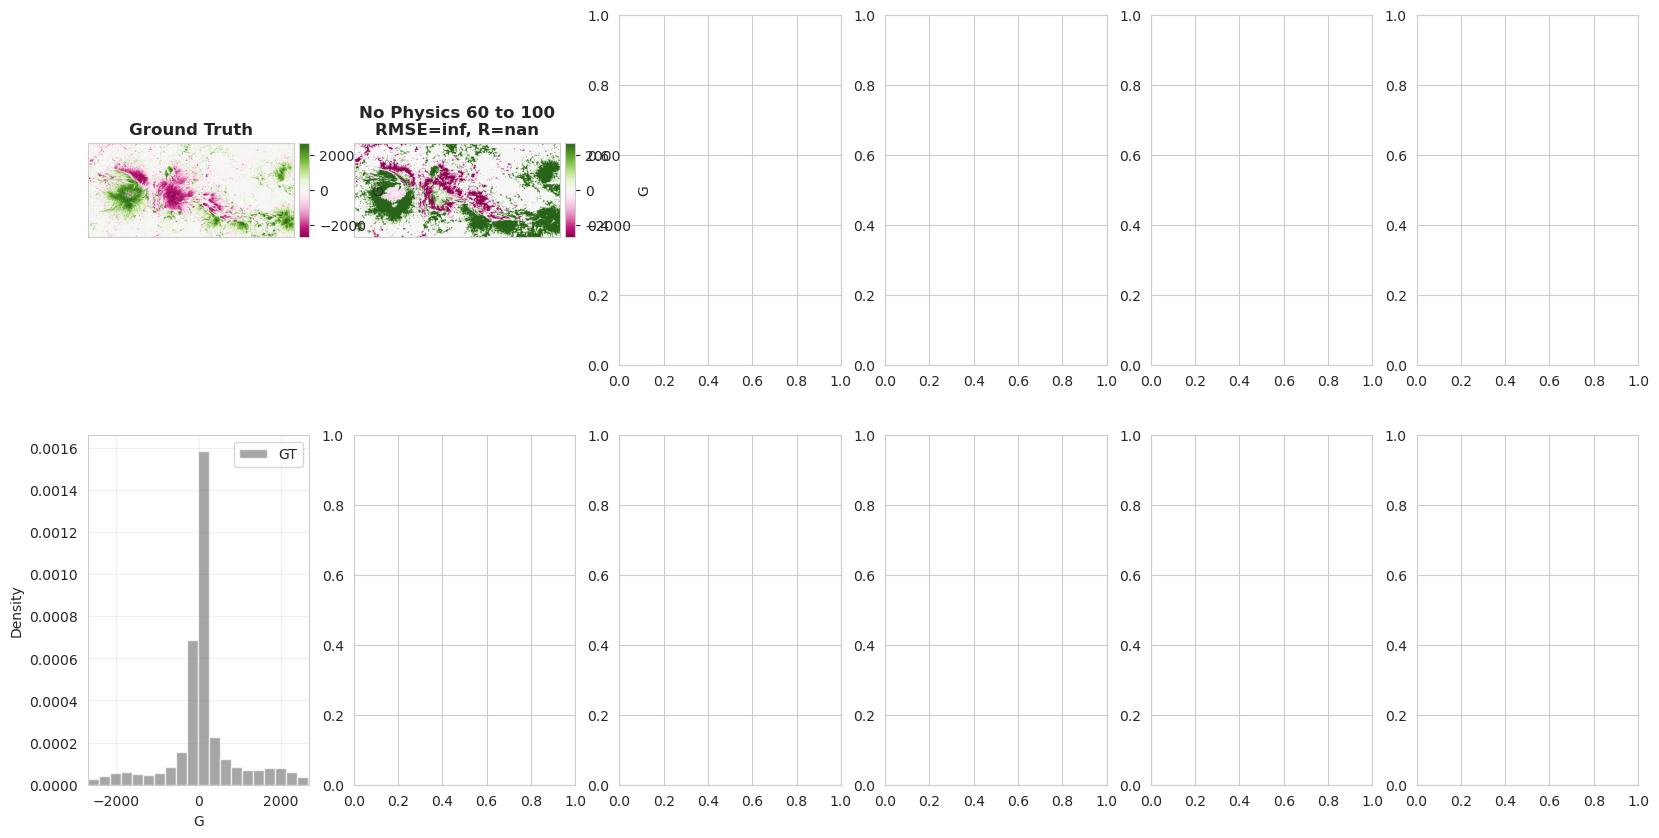

In [11]:
# Compare all models side-by-side
for od_to_plot in modest_logtau:
    for param in ['T', 'Vz', 'Bz']:
        filename = f"model_comparison_{param}_logtau_{od_to_plot}.png"
        try:
            compare_models_at_optical_depth(
                all_predictions=all_predictions,
                ground_truth=modest.spinor_atm,
                mag_to_plot=param,
                od_to_plot=od_to_plot,
                logtau=logtau,
                figsize=(20, 10),
                save_dir=images_save_path,
                filename=filename
            )
            print(f"✓ Saved model comparison plot for {param} at log(tau)={od_to_plot}")
        except Exception as e:
            print(f"Error comparing models for {param} at log(tau)={od_to_plot}: {e}")

## 9. Metrics Across Optical Depths

In [12]:
# Example 3: Compare all models with ground truth
for model_name, pred_data in all_predictions.items():
    filename = f"{pred_data['label'].lower().replace(' ', '_')}_mean_vs_optical_depth.png"
    print(f"\n{'='*80}")
    print(f"Model: {pred_data['label']}")
    print(f"{'='*80}")

    plot_mean_vs_optical_depth(
        mean_atm=pred_data['mean'],
        std_atm=pred_data['std'],
        logtau=logtau,
        figsize=(18, 6),
        log_scale={'T': False, 'Vz': False, 'Bz': False},
        ylims={'T': (2000, 7000), 'Vz': (-11, 7), 'Bz': (-2000, 2000)},
        ground_truth=modest.spinor_atm,
        save_dir=images_save_path,
        filename=filename
    )
    print(f"✓ Saved mean vs optical depth plot for {pred_data['label']}")


Model: No Physics 60 to 100


  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/mean_vs_optical_depth/no_physics_60_to_100_mean_vs_optical_depth.json

Ground Truth Comparison at Available Optical Depths

Temperature (K):
----------------------------------------------------------------------
  log(τ) =  -2.0:
    Ground Truth:      815.50 ±   739.42 K
    Model Pred:       3625.71 ±   584.74 K
    Difference:       2810.21 (+344.6%)
    Status:        ✗ OUTSIDE ±1σ uncertainty
  log(τ) =  -0.8:
    Ground Truth:     5227.71 ±   451.50 K
    Model Pred:       4631.99 ±   235.57 K
    Difference:       -595.72 (-11.4%)
    Status:        ✗ OUTSIDE ±1σ uncertainty
  log(τ) =   0.0:
    Ground Truth:     6107.60 ±   559.61 K
    Model Pred:       5896.94 ±   347.29 K
    Difference:       -210.65 (-3.4%)
    Status:        ✓ WITHIN ±1σ uncertainty

Line-of-sight Velocity (km/s):
----------------------------------------------------------------------
  log(τ) =

## 10. Seaborn-based Statistical Analysis

In [13]:
# 1. Separate jointplots for each model

for mag_to_plot in ["T", "Vz", "Bz"]:
    for od_to_plot in modest_logtau:
        try:
            print(f"\n{'='*80}")
            print(f"Separate Jointplots: {mag_to_plot}")
            print(f"{'='*80}")
            filename_prefix = f"jointplot_{mag_to_plot}_logtau_{od_to_plot}"
            plot_jointplot_comparison(
                all_predictions=all_predictions,
                ground_truth=modest.spinor_atm,
                mag_to_plot=mag_to_plot,
                od_val=od_to_plot,
                logtau=logtau,
                n_samples=10000,
                kind='reg',  # Options: 'scatter', 'hex', 'kde', 'reg',
                save_dir=images_save_path,
                filename_prefix=filename_prefix
            )
            print(f"✓ Saved jointplots for {mag_to_plot}")
        except Exception as e:
            print(f"Error plotting jointplots for {mag_to_plot}: {e}")


Separate Jointplots: T
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/jointplot_comparison/jointplot_T_logtau_-2.0_no_physics_60_to_100.json

No Physics 60 to 100 - Temperature at log(τ)=-2.0
  Pearson R:   -0.6370 (p=0.00e+00)
  RMSE:        4712.50 K
  Bias:        2761.15 K
  Samples:     10,000


  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/jointplot_comparison/jointplot_T_logtau_-2.0_wfa_only_60_to_100.json

WFA Only 60 to 100 - Temperature at log(τ)=-2.0
  Pearson R:   -0.6864 (p=0.00e+00)
  RMSE:        4251.71 K
  Bias:        2268.28 K
  Samples:     10,000
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/jointplot_comparison/jointplot_T_logtau_-2.0_all_physics_60_to_100.json

All Physics 60 to 100 - Temperature at log(τ)=-2.0
  Pearson R:   -0.6975 (p=0.00e+00)
  RMSE:        9327.82 K
  Bias:        -1870.87 K
  Samples:     10,000
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/jointplot_comparison/jointplot_T_logtau_-2.0_no_physics_100_to_200.json

No Physics 100 to 200 - Temperature at log(τ)=-2.0
  Pearson R:   -0.6446 (p=0.00e+00)
  RMSE:        4434.12 K
  Bias:        1454.

/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:1006: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean((pred_valid - gt_valid)**2))


  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/jointplot_comparison/jointplot_Bz_logtau_-0.8_wfa_only_100_to_200.json

WFA Only 100 to 200 - Line-of-sight Magnetic Field at log(τ)=-0.8
  Pearson R:   0.0238 (p=1.73e-02)
  RMSE:        inf G
  Bias:        512459383041425408.00 G
  Samples:     10,000
✓ Saved jointplots for Bz

Separate Jointplots: Bz


/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:1006: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean((pred_valid - gt_valid)**2))


  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/jointplot_comparison/jointplot_Bz_logtau_0.0_no_physics_60_to_100.json

No Physics 60 to 100 - Line-of-sight Magnetic Field at log(τ)=0.0
  Pearson R:   0.0188 (p=5.95e-02)
  RMSE:        inf G
  Bias:        168012059579631058060050432.00 G
  Samples:     10,000
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/jointplot_comparison/jointplot_Bz_logtau_0.0_wfa_only_60_to_100.json

WFA Only 60 to 100 - Line-of-sight Magnetic Field at log(τ)=0.0
  Pearson R:   -0.0119 (p=2.35e-01)
  RMSE:        151057841782784.00 G
  Bias:        -1730318303232.00 G
  Samples:     10,000


/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:1006: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean((pred_valid - gt_valid)**2))


  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/jointplot_comparison/jointplot_Bz_logtau_0.0_all_physics_60_to_100.json

All Physics 60 to 100 - Line-of-sight Magnetic Field at log(τ)=0.0
  Pearson R:   -0.0296 (p=3.08e-03)
  RMSE:        inf G
  Bias:        -153354146789546000384.00 G
  Samples:     10,000
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/jointplot_comparison/jointplot_Bz_logtau_0.0_no_physics_100_to_200.json

No Physics 100 to 200 - Line-of-sight Magnetic Field at log(τ)=0.0
  Pearson R:   0.0311 (p=1.86e-03)
  RMSE:        5699358720.00 G
  Bias:        128221696.00 G
  Samples:     10,000
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/jointplot_comparison/jointplot_Bz_logtau_0.0_wfa_only_100_to_200.json

WFA Only 100 to 200 - Line-of-sight Magnetic Field at log(τ)=0.0
  Pearso


Combined Jointplot: T


  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/combined_jointplot/combined_jointplot_T_logtau_-2.0.json

Combined Analysis: Temperature at log(τ)=-2.0

No Physics 60 to 100:
  Pearson R:   -0.6412 (p=0.00e+00)
  RMSE:        4745.24 K
  Bias:        2888.92 K
  Samples:     5,000

WFA Only 60 to 100:
  Pearson R:   -0.6767 (p=0.00e+00)
  RMSE:        4269.75 K
  Bias:        2231.90 K
  Samples:     5,000

All Physics 60 to 100:
  Pearson R:   -0.7117 (p=0.00e+00)
  RMSE:        9366.05 K
  Bias:        -1926.74 K
  Samples:     5,000

No Physics 100 to 200:
  Pearson R:   -0.6624 (p=0.00e+00)
  RMSE:        4444.42 K
  Bias:        1455.36 K
  Samples:     5,000

WFA Only 100 to 200:
  Pearson R:   -0.7736 (p=0.00e+00)
  RMSE:        5473.41 K
  Bias:        1090.82 K
  Samples:     5,000
✓ Saved combined jointplot for T

Combined Jointplot: T
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/im

/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:1169: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean((pred_valid - gt_valid)**2))


Error plotting combined jointplot for Bz: Maximum allowed size exceeded


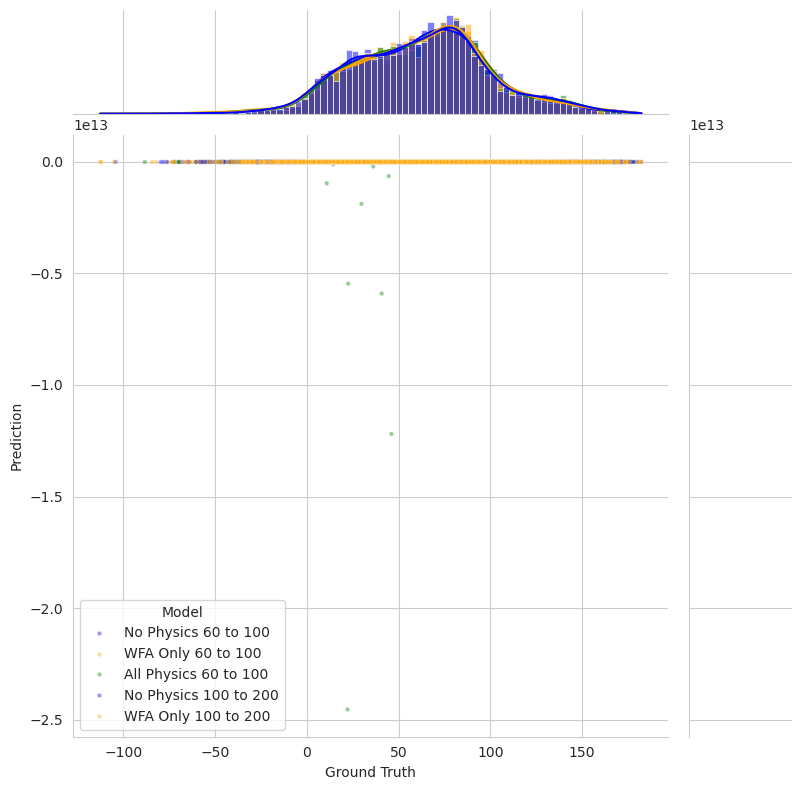

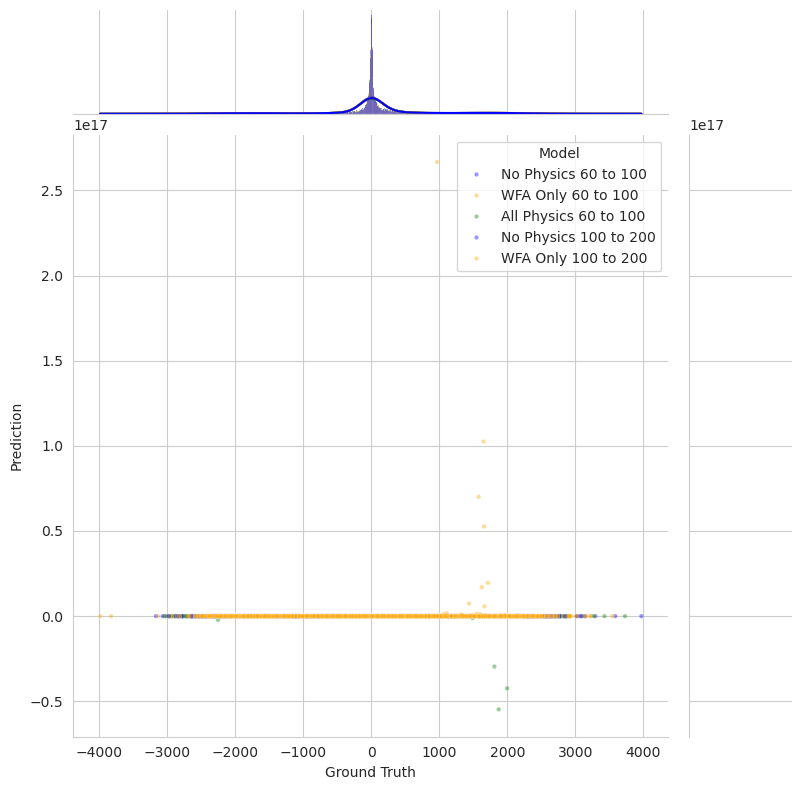

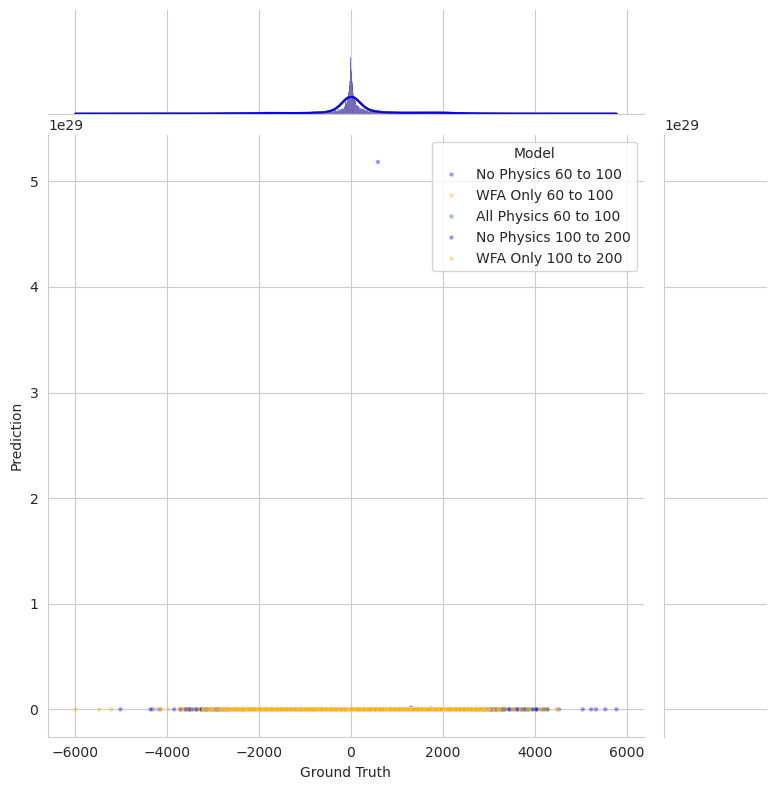

In [14]:
# 2. Combined jointplot with all models overlaid
for param in ['T', 'Vz', 'Bz']:
    for od_to_plot in modest_logtau:
        print(f"\n{'='*80}")
        print(f"Combined Jointplot: {param}")
        print(f"{'='*80}")
        filename = f"combined_jointplot_{param}_logtau_{od_to_plot}.png"
        try:
            plot_combined_jointplot(
                all_predictions=all_predictions,
                ground_truth=modest.spinor_atm,
                mag_to_plot=param,
                od_val=od_to_plot,
                logtau=logtau,
                n_samples=5000,
                save_dir=images_save_path,
                filename=filename
            )
            print(f"✓ Saved combined jointplot for {param}")
        except Exception as e:
            print(f"Error plotting combined jointplot for {param}: {e}")

## 11. Error Analysis by Magnitude

IndexError: index 3 is out of bounds for axis 0 with size 3

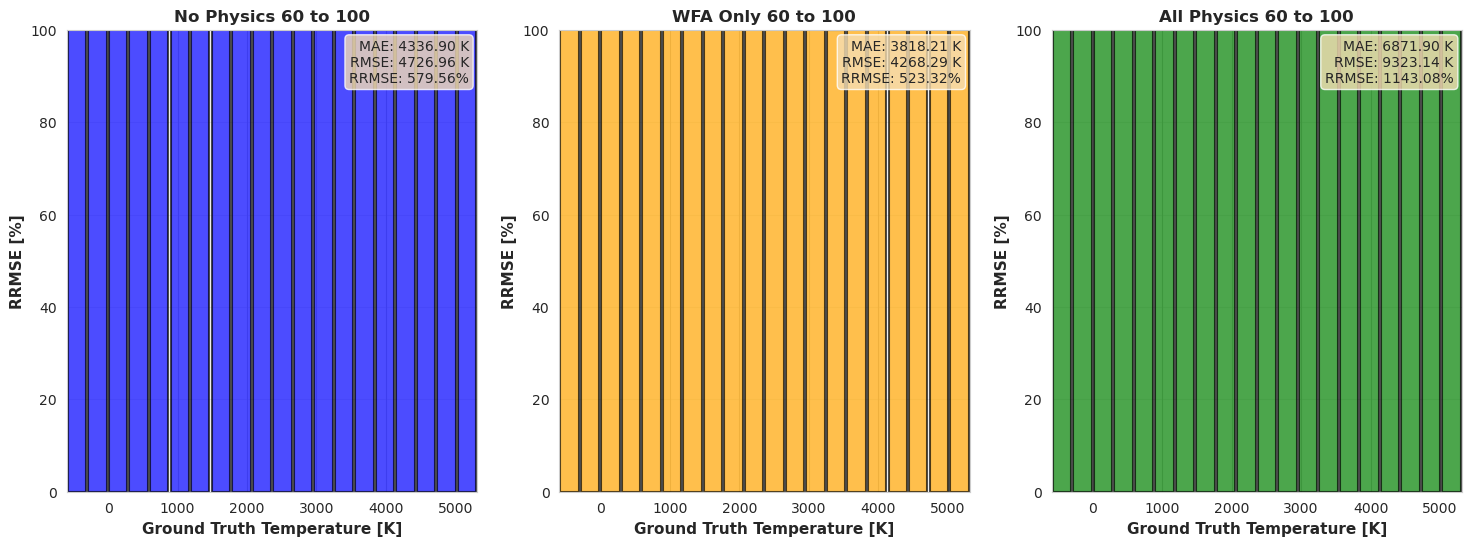

In [15]:
for param in ['T', 'Vz', 'Bz']:
    for od_to_plot in modest_logtau:
        filename = f"error_analysis_{param}_logtau_{od_to_plot}.png"
        analyze_error_by_magnitude(
            all_predictions=all_predictions,
            ground_truth=modest.spinor_atm,
            mag_to_analyze=param,  # Choose: "T", "Vz", or "Bz"
            od_val=od_to_plot,
            logtau=logtau,
            n_bins=20,
            plot_counts=False,
            use_absolute=False,
            rrmse_ylim=(0, 100),
            save_dir=images_save_path,
            filename=filename
        )
        print(f"✓ Saved error analysis plot for {param} at log(tau)={od_to_plot}")

## 12. Uncertainty Quantification Analysis

In [ ]:
# Run uncertainty analysis
for param in ['T', 'Vz', 'Bz']:
    for od_to_plot in modest_logtau:
        filename = f"uncertainty_vs_error_{param}_logtau_{od_to_plot}.png"
        plot_uncertainty_vs_error(
            all_predictions=all_predictions,
            ground_truth=modest.spinor_atm,
            mag_to_plot=param,
            od_val=od_to_plot,
            logtau=logtau,
            save_dir=images_save_path,
            filename=filename
        )
        print(f"✓ Saved uncertainty vs error plot for {param} at log(tau)={od_to_plot}")

✓ Saved uncertainty vs error plot for T at log(tau)=-2.0
✓ Saved uncertainty vs error plot for T at log(tau)=-0.8
✓ Saved uncertainty vs error plot for T at log(tau)=0.0
✓ Saved uncertainty vs error plot for Vz at log(tau)=-2.0
✓ Saved uncertainty vs error plot for Vz at log(tau)=-0.8
✓ Saved uncertainty vs error plot for Vz at log(tau)=0.0
✓ Saved uncertainty vs error plot for Bz at log(tau)=-2.0


/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4623: RuntimeWarning: invalid value encountered in subtract
  xm = x - xmean


✓ Saved uncertainty vs error plot for Bz at log(tau)=-0.8
✓ Saved uncertainty vs error plot for Bz at log(tau)=0.0
